# Positional Encoding From Scratch

### Check torch version

In [14]:
from importlib.metadata import version
print("torch version: ", version("torch"))

torch version:  2.7.0+cu128


### Implementation

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import math
import seaborn as sns

from dataclasses import dataclass

In [16]:
@dataclass
class Args:
    T: int # token sequence length 
    D: int # embedding dimension of each token    

In [17]:
class PositionalEncoding(nn.Module):
    """
    formula:
    pe(pos, 2i) = sin(pos * ((10000)^{-2i / D})) = sin(pos * factor)
    pe(pos, 2i+1) = cos(pos * ((10000)^{-2i / D})) = sin(pos * factor)
    """
    def __init__(self, args):
        super().__init__()

        # initialize pe
        # pe shape = [T, D]
        pe = torch.zeros(args.T, args.D)

        # position shape = [T, 1]
        position = torch.arange(0, args.T).unsqueeze(1)

        # compute factor
        # compute log(factor) first: 10000^{-2i / D} = (-2i / D) * log(10000)
        # then compute exp(log(factor))
        factor = -1 * torch.arange(0, args.D, 2) / args.D * math.log(10000.0)
        factor = torch.exp(factor)

        # compute pe
        pe[:, 0::2] = torch.sin(position * factor)
        pe[:, 1::2] = torch.cos(position * factor)

        # add batch dimension
        # pe shape = [B, T, D]
        pe = pe.unsqueeze(0)

        # register pe, pe is not in the gradient computation
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x shape = [B, T, D]
        x = x + self.pe

        return x

        

### Test & visualization

In [18]:
# set hyperparameters
B = 32
T = 512
D = 1024

# instantiate Args
args = Args(T, D)
print("T: ", args.T, "D: ", args.D)

# test PositionalEncoding
# note postional encoding pe is irrelevant to input x
positional_encoder = PositionalEncoding(args)
print("positional encoding shape: ", positional_encoder.pe.shape)



T:  512 D:  1024


positional encoding shape:  torch.Size([1, 512, 1024])


<Axes: >

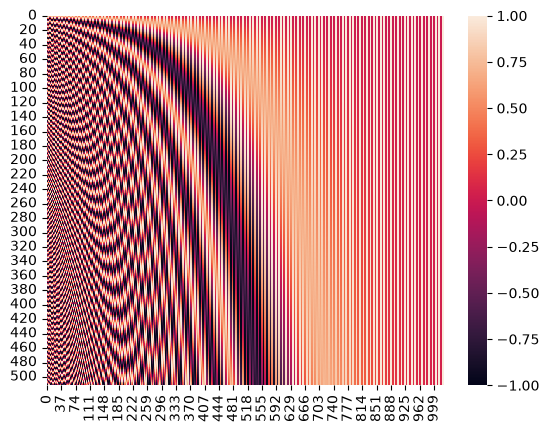

In [19]:
# visualize pe
# the first batch
pe_numpy = positional_encoder.pe[0].detach().numpy()
sns.heatmap(pe_numpy)